In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('IRIS.csv')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [8]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

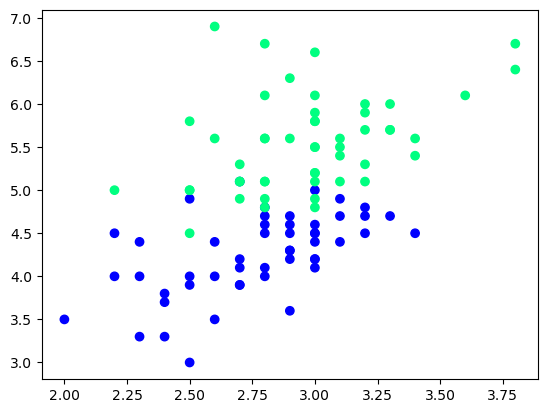

In [10]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [11]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [12]:
df_train

,sepal_width,petal_length,species
143,3.2,5.9,2
79,2.6,3.5,1
148,3.4,5.4,2
139,3.1,5.4,2
113,2.5,5.0,2
103,2.9,5.6,2
96,2.9,4.2,1
89,2.5,4.0,1
115,3.2,5.3,2
86,3.1,4.7,1


In [13]:
df_val

,sepal_width,petal_length,species
129,3.0,5.8,2
56,3.3,4.7,1
125,3.2,6.0,2
136,3.4,5.6,2
141,3.1,5.1,2


In [14]:
df_test

,sepal_width,petal_length,species
112,3.0,5.5,2
82,2.7,3.9,1
134,2.6,5.6,2
137,3.1,5.5,2
99,2.8,4.1,1


In [15]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [16]:
X_test

array([[3. , 5.8],
       [3.3, 4.7],
       [3.2, 6. ],
       [3.4, 5.6],
       [3.1, 5.1]])

In [17]:
y_test

array([2, 1, 2, 2, 2])

# Case 1 - Bagging

In [18]:
# Data for Tree 1 Replace = TRue means same row can be selected twice.
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
86,3.1,4.7,1
103,2.9,5.6,2
113,2.5,5.0,2
148,3.4,5.4,2
96,2.9,4.2,1
139,3.1,5.4,2
143,3.2,5.9,2
113,2.5,5.0,2


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [20]:
dt_bag1 = DecisionTreeClassifier()

In [21]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values,y.values,clf=clf,legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

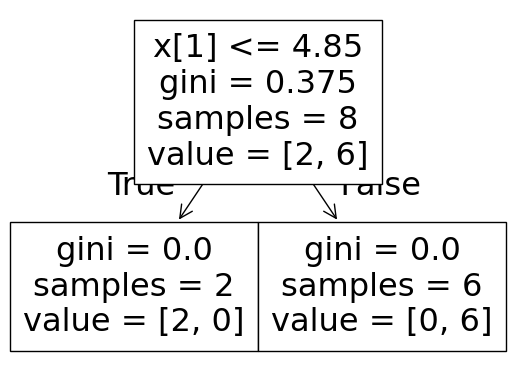

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


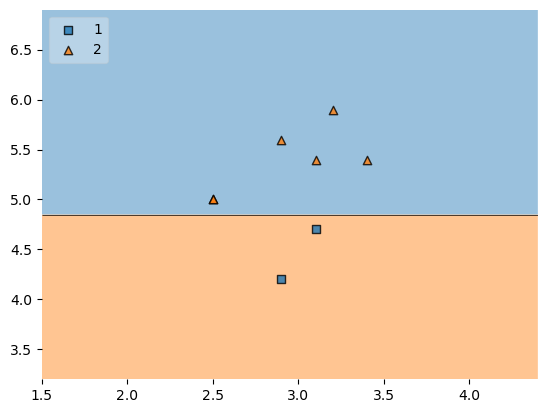

In [22]:
evaluate(dt_bag1,X,y)

In [23]:
# data for tree 2
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
103,2.9,5.6,2
86,3.1,4.7,1
143,3.2,5.9,2
148,3.4,5.4,2
139,3.1,5.4,2
86,3.1,4.7,1
115,3.2,5.3,2
113,2.5,5.0,2


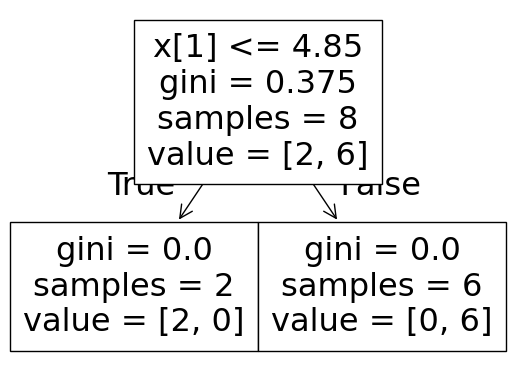

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


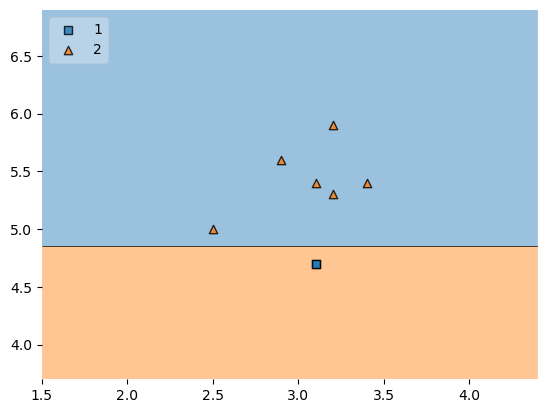

In [24]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [25]:
# data for tree 3
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
86,3.1,4.7,1
113,2.5,5.0,2
86,3.1,4.7,1
79,2.6,3.5,1
86,3.1,4.7,1
79,2.6,3.5,1
79,2.6,3.5,1
103,2.9,5.6,2


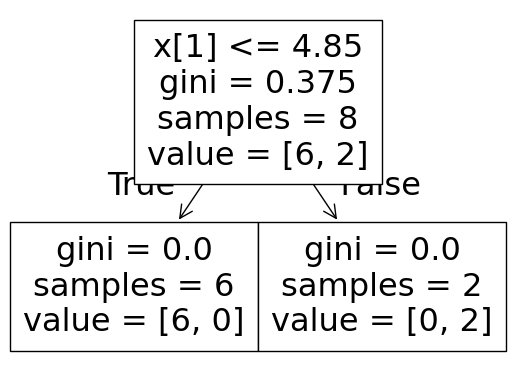

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


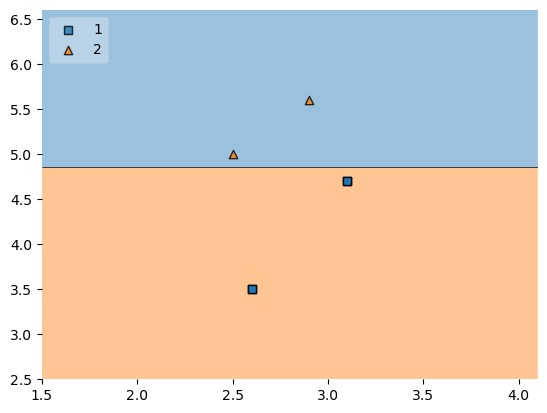

In [26]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

# Predict

In [27]:
df_test

,sepal_width,petal_length,species
112,3.0,5.5,2
82,2.7,3.9,1
134,2.6,5.6,2
137,3.1,5.5,2
99,2.8,4.1,1


In [28]:
print("Predictor 1", dt_bag1.predict(np.array([3.3,5.7]).reshape(1,2)))
print("Predictor 2", dt_bag2.predict(np.array([3.3,5.7]).reshape(1,2)))
print("Predictor 2", dt_bag3.predict(np.array([3.3,5.7]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 2 [2]


C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [29]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
143,3.2,5.9,2
79,2.6,3.5,1
148,3.4,5.4,2
139,3.1,5.4,2
113,2.5,5.0,2
103,2.9,5.6,2
96,2.9,4.2,1
89,2.5,4.0,1
115,3.2,5.3,2
86,3.1,4.7,1


In [30]:
# here we dont do replace.  that is the only difference
df_train.sample(8)

,sepal_width,petal_length,species
143,3.2,5.9,2
86,3.1,4.7,1
115,3.2,5.3,2
89,2.5,4.0,1
103,2.9,5.6,2
79,2.6,3.5,1
96,2.9,4.2,1
148,3.4,5.4,2


# Random Subspaces

In [31]:
# col sampling

In [32]:
df1 = pd.read_csv('IRIS.csv')

In [33]:
df1.sample(2,replace=True,axis=1)

,petal_width,species
0,0.2,Iris-setosa
1,0.2,Iris-setosa
2,0.2,Iris-setosa
3,0.2,Iris-setosa
4,0.2,Iris-setosa
...,...,...
145,2.3,Iris-virginica
146,1.9,Iris-virginica
147,2.0,Iris-virginica
148,2.3,Iris-virginica


# Random Patches

In [34]:
# both col as well as row sampling

In [35]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [36]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal_length,sepal_width
102,7.1,3.0
31,5.4,3.4
50,7.0,3.2
124,6.7,3.3
125,7.2,3.2
112,6.8,3.0
29,4.7,3.2
50,7.0,3.2
